In [267]:
import matplotlib.pyplot as plt
import json
import pickle as pkl
import os
import numpy as np
from collections import defaultdict
from scipy.stats import pearsonr


In [268]:
# parent = r"C:\__NeuroSpark_Liset_Dataset__\neurospark_mat\CNN_TRAINING_SESSIONS" # Modify this to your data path folder
parent = r"C:\__NeuroSpark_Liset_Dataset__\neurospark_mat\Download_from_paper" # Modify this to your data path folder
# parent=r"E:\neurospark_mat\CNN_TRAINING_SESSIONS"
# parent=r"E:\neurospark_mat\Download_from_paper"

bandpass=[100,250]
downsampled_fs = 30000 # Downsampled frequency
factor=downsampled_fs//1000
time_max=20
window_size=0.1
sample_ratio=0.25
scaling_factor=1
refractory=0.0003
percentile=False
fraction=(0,1)
downsample_factor=30000//downsampled_fs
overlap=int(time_max/2)

In [269]:
adaptive_thresholds=0
load_path = os.path.join(os.getcwd())
filename = f"thresholds_and_spikerates_adapt{time_max}.pkl" if adaptive_thresholds else f"thresholds_and_spikerates_fixed{time_max}.pkl"
file_path = os.path.join(load_path, filename)
with open(file_path, "rb") as f:
    data = pkl.load(f)
    thresholds = data["thresholds"]
    spike_rates = data["spike_rates"]

In [270]:
dataset_colors={
   "Amigo": "#8E44AD",
   "Dlx": "#E74C3C",
   "Som": "#FFC300",
   "Thy": "#17BECF"
}

In [271]:
# Example: extract X% of precomputed thresholds
fraction_start =  0.8 
fraction_end = 1.0

extracted_thresholds = {}
extracted_spike_rates = {}
for dataset in thresholds:
    dataset_thresholds = thresholds[dataset]
    dataset_spikerates = spike_rates[dataset]
    extracted_dataset_thresholds = {}
    extracted_dataset_spikerates = {}

    for channel in dataset_thresholds:
        channel_thresholds = dataset_thresholds[channel]
        channel_spikerates = dataset_spikerates[channel]
        total_windows = len(channel_thresholds)

        start_idx = int(fraction_start * total_windows)
        end_idx = int(fraction_end * total_windows)

        extracted_dataset_thresholds[channel] = channel_thresholds[start_idx:end_idx]
        extracted_dataset_spikerates[channel] = channel_spikerates[start_idx:end_idx]

    extracted_spike_rates[dataset] = extracted_dataset_spikerates
    extracted_thresholds[dataset] = extracted_dataset_thresholds


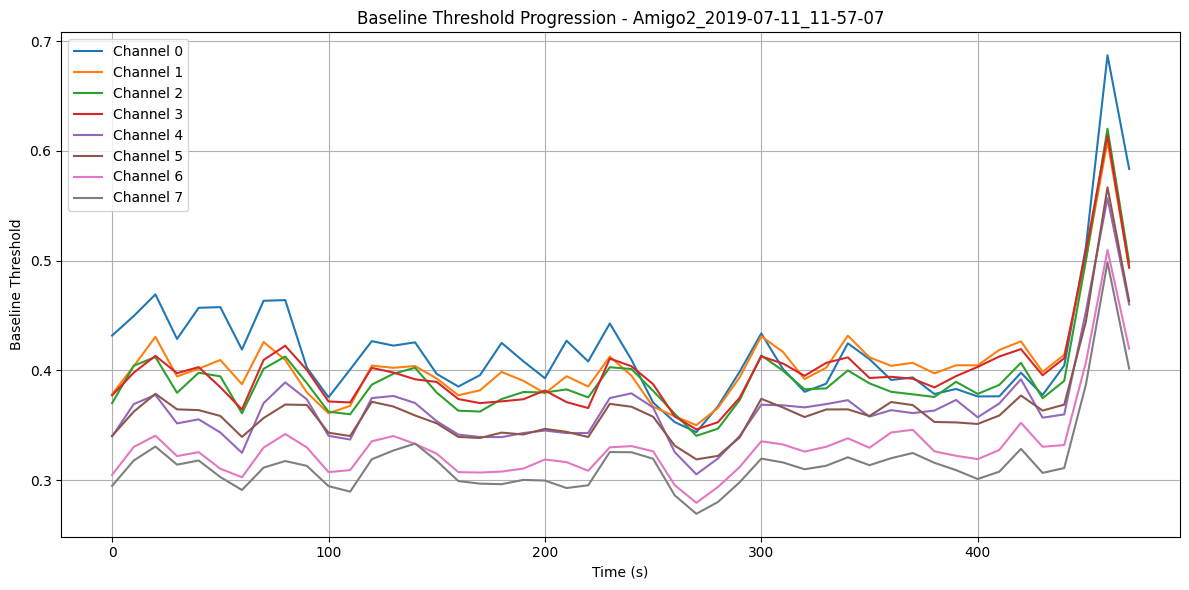

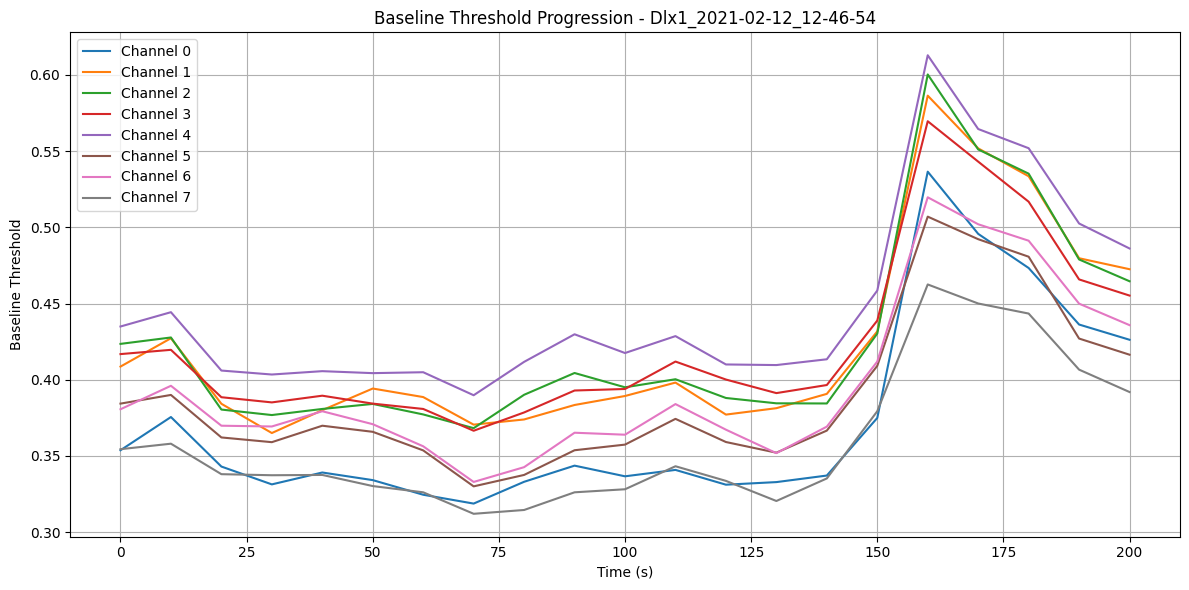

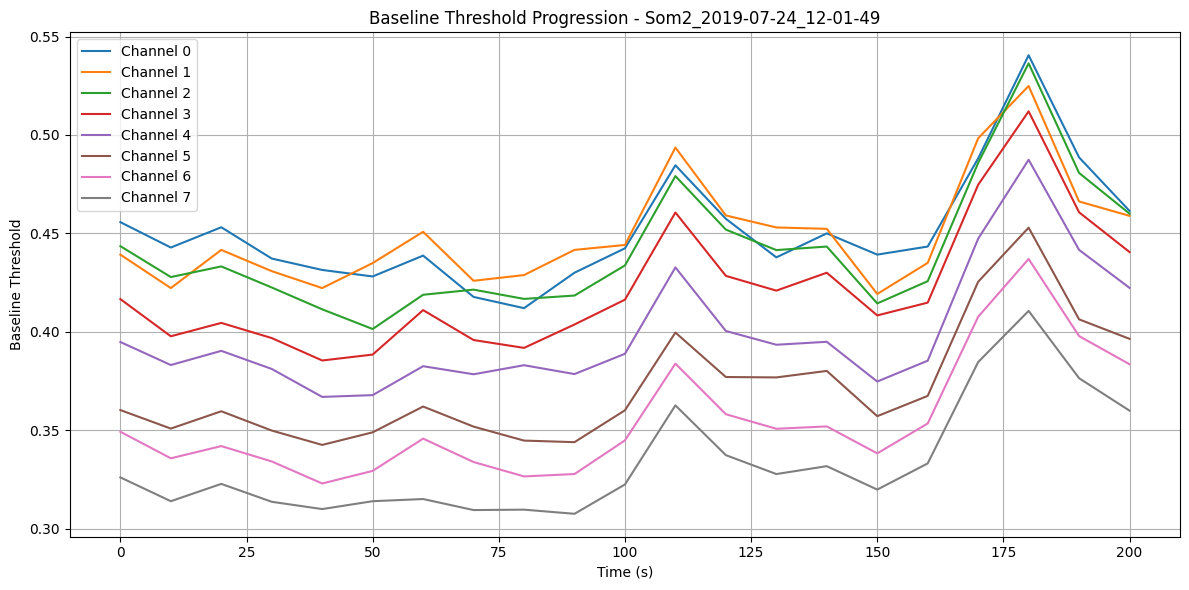

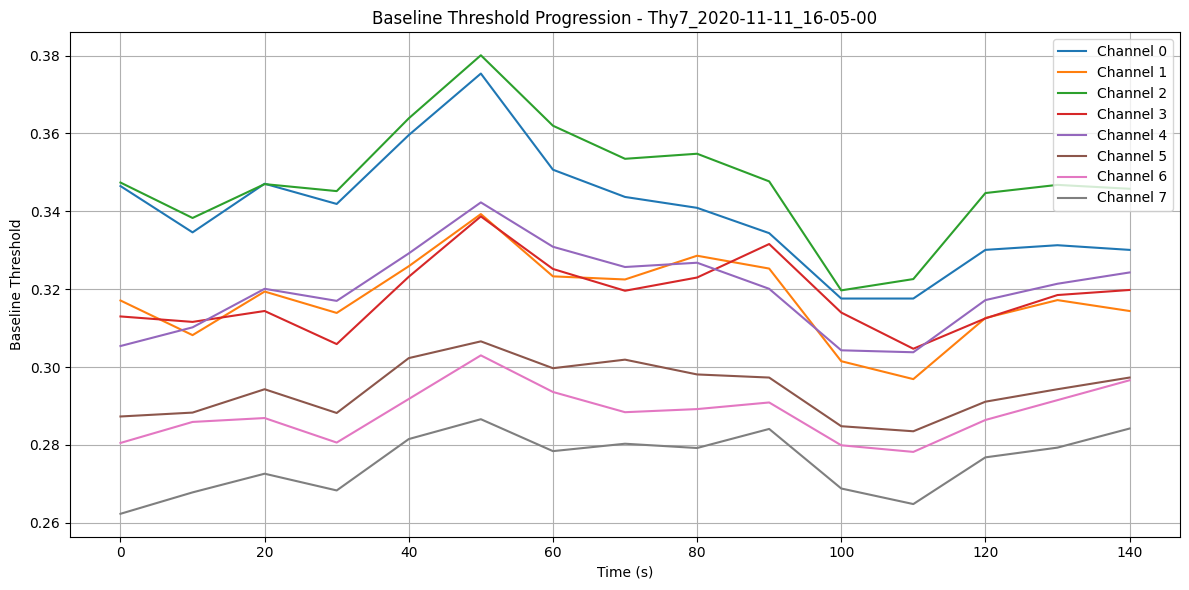

In [272]:
# Evolution of thresholds with time

# Loop through each dataset
for dataset_name, channel_dict in extracted_thresholds.items():
    
    plt.figure(figsize=(12, 6))
    plt.title(f"Baseline Threshold Progression - {dataset_name}")
    
    # Loop through each channel
    for channel, threshold_list in channel_dict.items():
        time_axis = [i * overlap for i in range(len(threshold_list))]
        plt.plot(time_axis,threshold_list, label=f"Channel {channel}")
        if channel=="0":
            print()
    
    plt.xlabel("Time (s)")
    plt.ylabel("Baseline Threshold")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

Processing dataset: Amigo2_2019-07-11_11-57-07
Dataset: Amigo2_2019-07-11_11-57-07, Pearson r = 0.425, p = 1.840e-84


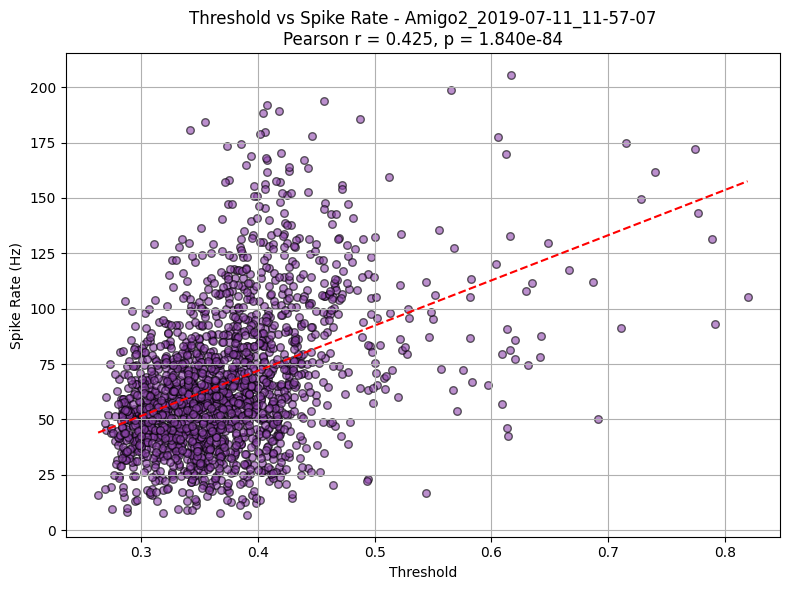

Processing dataset: Dlx1_2021-02-12_12-46-54
Dataset: Dlx1_2021-02-12_12-46-54, Pearson r = 0.351, p = 7.864e-25


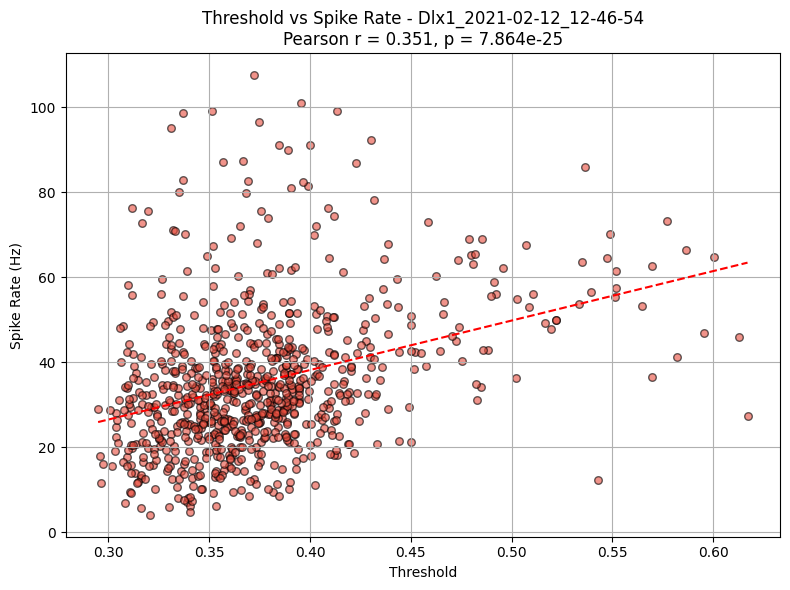

Processing dataset: Som2_2019-07-24_12-01-49
Dataset: Som2_2019-07-24_12-01-49, Pearson r = 0.282, p = 2.175e-16


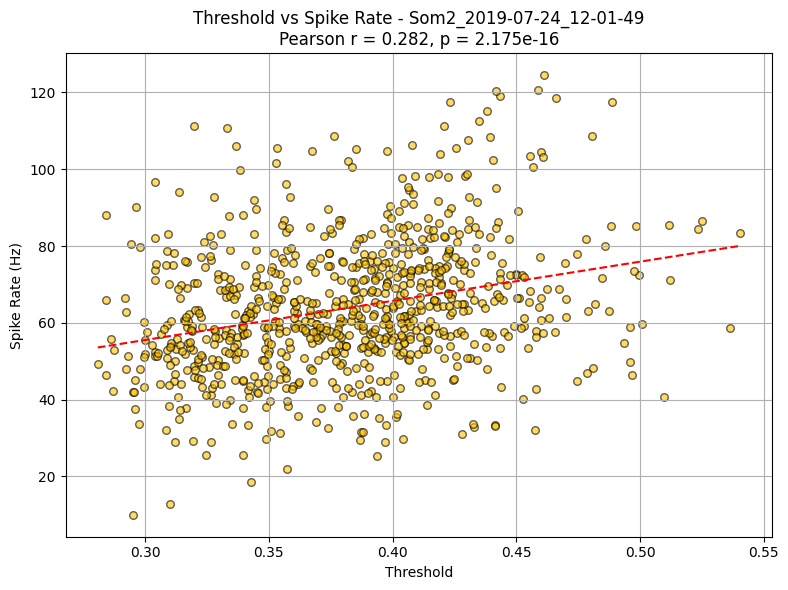

Processing dataset: Thy7_2020-11-11_16-05-00
Dataset: Thy7_2020-11-11_16-05-00, Pearson r = 0.344, p = 1.237e-17


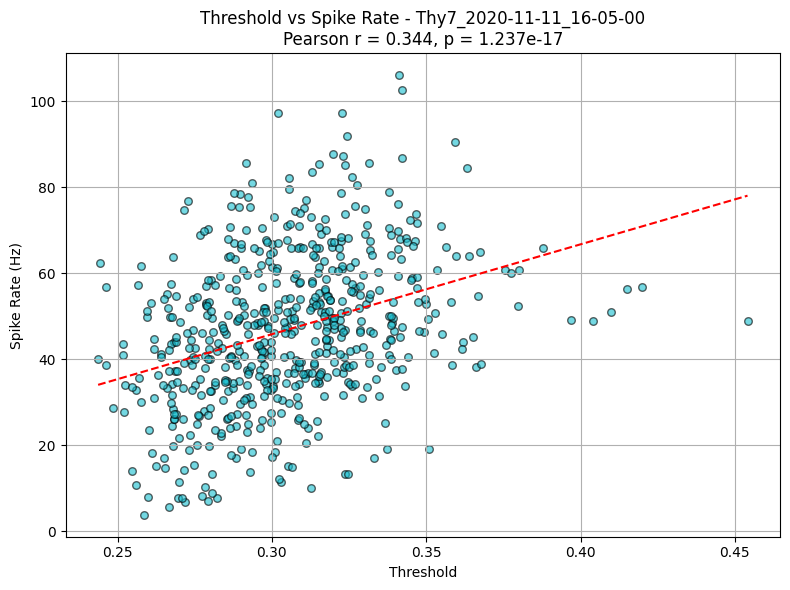

In [273]:
from scipy.stats import pearsonr

# colors = plt.cm.tab10.colors  # color palette
labels=["Amigo", "Dlx", "Som", "Thy"]
# Store for overall plot
threshold_all = []
spike_all = []
dataset_labels = []

for i, dataset_name in enumerate(thresholds.keys()):
    thresholds_dataset = []
    spikerates_dataset = []
    print(f"Processing dataset: {dataset_name}")
    for channel in thresholds[dataset_name].keys():
        channel_rates = spike_rates[dataset_name][channel]
        channel_thresholds = thresholds[dataset_name][channel]
        if len(channel_rates) != len(channel_thresholds):
            print(f"Length mismatch for dataset {dataset_name}, channel {channel}: {len(channel_rates)} vs {len(channel_thresholds)}")
        thresholds_dataset.extend(channel_thresholds)
        spikerates_dataset.extend(channel_rates)

    # Switched axis in correlation
    r_val, p_val = pearsonr(thresholds_dataset, spikerates_dataset)

    threshold_all.extend(thresholds_dataset)
    spike_all.extend(spikerates_dataset)
    dataset_labels.extend([dataset_name] * len(spikerates_dataset))

    print(f"Dataset: {dataset_name}, Pearson r = {r_val:.3f}, p = {p_val:.3e}")
    plt.figure(figsize=(8, 6))

    # Switched axis in plot
    plt.scatter(thresholds_dataset, spikerates_dataset, alpha=0.6, s=30,
                c=dataset_colors[labels[i]], edgecolors='k')

    # Switched x and y for trendline
    slope, intercept = np.polyfit(thresholds_dataset, spikerates_dataset, 1)
    x_vals = np.array([min(thresholds_dataset), max(thresholds_dataset)])
    y_vals = slope * x_vals + intercept
    plt.plot(x_vals, y_vals, color='red', linestyle='--', label='Trendline')

    plt.title(f"Threshold vs Spike Rate - {dataset_name}\nPearson r = {r_val:.3f}, p = {p_val:.3e}")
    plt.xlabel("Threshold")
    plt.ylabel("Spike Rate (Hz)")
    plt.grid(True)
    plt.tight_layout()
    plt.show()

Overall Pearson r = 0.377, p = 9.34e-139
Spearman ρ = 0.323, p = 3.38e-100
Figure saved to: baseline_threshold_vs_spike_rate.png


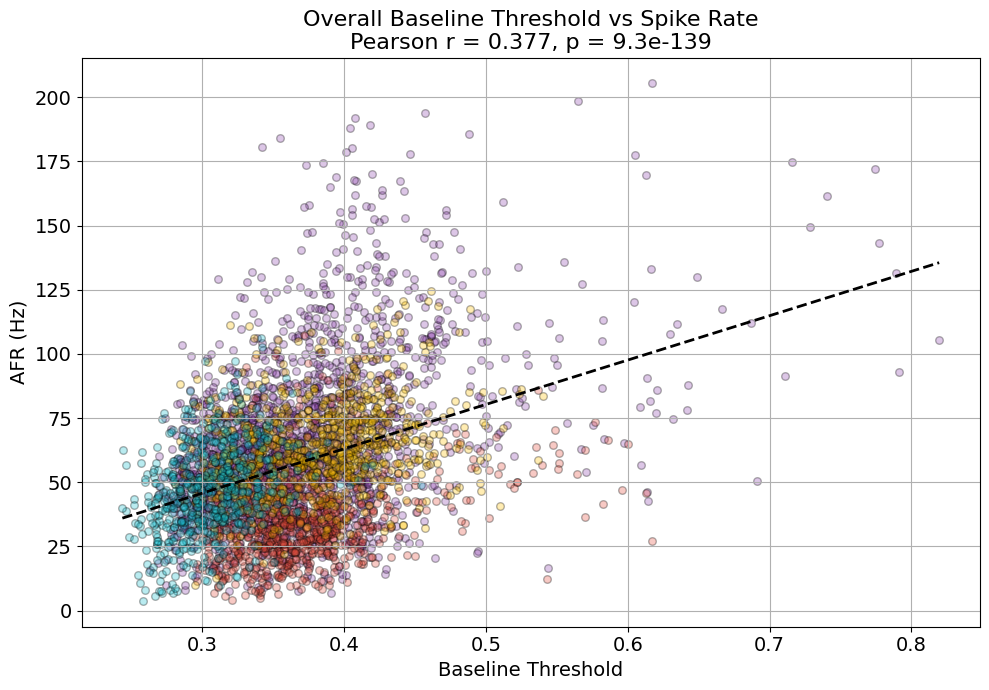

In [274]:
# Create fig and ax
fig, ax = plt.subplots(figsize=(10, 7))

unique_datasets = list(thresholds.keys())

for i, dataset_name in enumerate(unique_datasets):
    # Mask for current dataset
    mask = [label == dataset_name for label in dataset_labels]
    ax.scatter(
        [threshold_all[j] for j in range(len(threshold_all)) if mask[j]],  # x-axis
        [spike_all[j] for j in range(len(spike_all)) if mask[j]],          # y-axis
        alpha=0.3, s=30,
        c=[dataset_colors[labels[i]]], edgecolors='k',
        label=dataset_name
    )

# Overall correlation
r_all, p_all = pearsonr(threshold_all, spike_all)
print(f"Overall Pearson r = {r_all:.3f}, p = {p_all:.2e}")

# Fit and plot overall trendline
slope, intercept = np.polyfit(threshold_all, spike_all, 1)
x_vals = np.array([min(threshold_all), max(threshold_all)])
y_vals = slope * x_vals + intercept
ax.plot(x_vals, y_vals, color='black', linestyle='--', linewidth=2,label='Overall Trendline')

from scipy.stats import spearmanr
rho, p_rho = spearmanr(threshold_all, spike_all)
print(f"Spearman ρ = {rho:.3f}, p = {p_rho:.2e}")

# Labels and formatting
ax.set_title(f"Overall Baseline Threshold vs Spike Rate\nPearson r = {r_all:.3f}, p = {p_all:.1e}", fontsize=16)
ax.set_xlabel("Baseline Threshold",fontsize=14)
ax.set_ylabel("AFR (Hz)",fontsize=14)
ax.tick_params(axis='both', which='major', labelsize=14)
# ax.legend()
ax.grid(True)



# Save figure
save_path = "baseline_threshold_vs_spike_rate.png"
fig.tight_layout()
fig.savefig(save_path, dpi=300)
print(f"Figure saved to: {save_path}")

Figure saved to: stacked_hist_thresholds.png


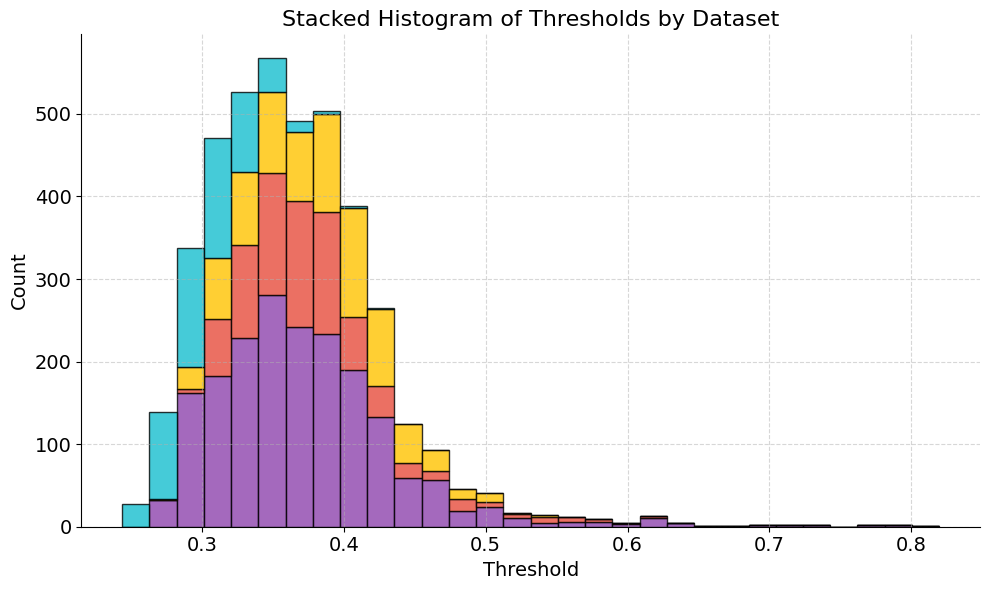

In [275]:
import matplotlib.pyplot as plt

# Create stacked histogram of thresholds by dataset
fig, ax = plt.subplots(figsize=(10, 6))

unique_datasets = list(thresholds.keys())

# Gather thresholds per dataset
thresholds_by_dataset = []
for ds in unique_datasets:
    thresholds_by_dataset.append([
        threshold_all[i] for i in range(len(threshold_all)) if dataset_labels[i] == ds
    ])

# Colors following your labels mapping
dataset_colors_list = [dataset_colors[label] for label in labels[:len(unique_datasets)]]

# Plot stacked histogram
ax.hist(
    thresholds_by_dataset,
    bins=30,               # adjust bin size as needed
    stacked=True,
    color=dataset_colors_list,
    label=unique_datasets,
    alpha=0.8,
    edgecolor='black'
)

ax.set_xlabel("Threshold", fontsize=14)
ax.set_ylabel("Count",fontsize=14)
ax.set_title("Stacked Histogram of Thresholds by Dataset",fontsize=16)
ax.tick_params(axis='both', which='major', labelsize=14)
# Uncomment the next line if you want to add a legend
# ax.legend(title="Dataset")
fig.tight_layout()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.grid(True,linestyle='--', alpha=0.5  )
# Save
save_path = "stacked_hist_thresholds.png"
fig.savefig(save_path, dpi=300)
print(f"Figure saved to: {save_path}")


## Evaluate Results


In [295]:
adapt=0
identifier="30000_1000_100"
identifier=f"{identifier}_adaptable{adapt}" if adapt>0 else f"{identifier}"
# identifier="1000_200_median"
dataset_path=os.path.join(os.getcwd(),os.pardir,"train_pedro","dataset_up_down",identifier)
datasets=os.listdir(dataset_path)
if "config.json" in datasets:
    datasets.remove("config.json")

results_path=os.path.join(os.getcwd(),os.pardir,os.pardir,"snnTorch","eval","live_results")
filename=f"all_network_results_{identifier}.pkl"
path_file=os.path.join(results_path, filename)
with open(path_file, "rb") as f:
    all_results = pkl.load(f)
    print(f"Loaded {len(all_results)} results from {filename}")

Loaded 12 results from all_network_results_30000_1000_100.pkl


In [296]:
# # Load results
# with open(results_json, 'r') as f:
#     results = json.load(f)
# # Load spikes
# spikes = np.load(spikes, allow_pickle=True)

In [297]:
# # Get some parameters
# parameters=results["parameters"]
# ripple_detection_offset=parameters["ripple_detection_offset"]

# refractory_period=parameters["refractory_period_gt"]
refractory_period=0 # in ms

# max_detection_offset=parameters["max_detection_offset"]

# tolerance=parameters["tolerance"]
tolerance=20 # in ms
padding=100 # in ms
max_detection_offset=80 # in ms
jitter=100

In [298]:
# Nested structure: net -> dataset -> channel -> window_idx -> metrics dict
threshold_tp_fp_fn_by_window = defaultdict(
    lambda: defaultdict(lambda: defaultdict(dict))
)

# Nested structure: net -> dataset -> channel -> list of metrics
window_metrics_by_dataset = defaultdict(
    lambda: defaultdict(lambda: defaultdict(lambda: defaultdict(list)))
)

# NEW OUTER LOOP
for net_name, information_dataset in all_results.items():
    for dataset_name, info in information_dataset.items():
        data_path = os.path.join(dataset_path, dataset_name)
        ripple_hits = info["ripple_hits"]
        ripples = np.load(os.path.join(data_path, "ripples.npy"))
        data = np.load(os.path.join(data_path, "spike_data.npy"))
        filtered_spikes = info["filtered_spikes"]

        for ch, ch_spikes in enumerate(filtered_spikes):
            ch_thresholds = extracted_thresholds[dataset_name][str(ch)]
            ch_rates = extracted_spike_rates[dataset_name][str(ch)]

            max_time = int(data.shape[0])
            n_windows = int(np.ceil(max_time / (overlap * 1000)))

            for window_idx in range(n_windows):
                start_time = window_idx * overlap * 1000
                end_time = start_time + overlap * 1000
                spikes_in_window = ch_spikes[(ch_spikes >= start_time) & (ch_spikes < end_time)]

                ripples_in_window = []
                ripple_ids_in_window = []
                for i, ripple in enumerate(ripples):
                    ripple_start = ripple[0] - tolerance
                    ripple_end = ripple[0] + max_detection_offset + tolerance
                    if not (ripple_end < start_time or ripple_start > end_time):
                        ripples_in_window.append((ripple_start, ripple_end))
                        ripple_ids_in_window.append(i)

                TP = 0
                FP = 0
                FN = 0
                matched_spikes = set()

                for ripple_idx in ripple_ids_in_window:
                    if ripple_idx in ripple_hits and ch in ripple_hits[ripple_idx]:
                        TP += 1
                    else:
                        FN += 1

                for spike_time in spikes_in_window:
                    for r_start, r_end in ripples_in_window:
                        if r_start-tolerance <= spike_time <= r_start +max_detection_offset + tolerance:
                            matched_spikes.add(spike_time)
                            break

                last_fp_time = -np.inf
                for spike_time in spikes_in_window:
                    if spike_time in matched_spikes:
                        continue
                    if any(spike_time <= r_start +max_detection_offset + tolerance + padding for (r_start, _) in ripples_in_window):
                        continue
                    if spike_time - last_fp_time > jitter:
                        FP += 1
                        last_fp_time = spike_time

                # Fetch threshold + rate
                threshold = ch_thresholds[window_idx] if window_idx < len(ch_thresholds) else None
                rate = ch_rates[window_idx] if window_idx < len(ch_rates) else None

                # ✅ Store per-network results
                threshold_tp_fp_fn_by_window[net_name][dataset_name][ch][window_idx] = {
                    "TP": TP, "FP": FP, "FN": FN, "threshold": threshold, "rate": rate
                }
                window_metrics_by_dataset[net_name][dataset_name][ch]["TP"].append(TP)
                window_metrics_by_dataset[net_name][dataset_name][ch]["FP"].append(FP)
                window_metrics_by_dataset[net_name][dataset_name][ch]["FN"].append(FN)
                window_metrics_by_dataset[net_name][dataset_name][ch]["threshold"].append(threshold)
                window_metrics_by_dataset[net_name][dataset_name][ch]["rate"].append(rate)

                print(f"[{net_name}] Dataset: {dataset_name}, Channel: {ch}, Window: {window_idx}, "
                      f"TP: {TP}, FP: {FP}, FN: {FN}, Threshold: {threshold}, Rate: {rate}")


[dsb4updn_median_200_15f] Dataset: Amigo2_2019-07-11_11-57-07, Channel: 0, Window: 0, TP: 10, FP: 6, FN: 0, Threshold: 0.4317, Rate: 120.0
[dsb4updn_median_200_15f] Dataset: Amigo2_2019-07-11_11-57-07, Channel: 0, Window: 1, TP: 6, FP: 3, FN: 1, Threshold: 0.4495, Rate: 129.1
[dsb4updn_median_200_15f] Dataset: Amigo2_2019-07-11_11-57-07, Channel: 0, Window: 2, TP: 3, FP: 3, FN: 0, Threshold: 0.4692, Rate: 131.85
[dsb4updn_median_200_15f] Dataset: Amigo2_2019-07-11_11-57-07, Channel: 0, Window: 3, TP: 5, FP: 1, FN: 0, Threshold: 0.4286, Rate: 137.95
[dsb4updn_median_200_15f] Dataset: Amigo2_2019-07-11_11-57-07, Channel: 0, Window: 4, TP: 8, FP: 1, FN: 1, Threshold: 0.457, Rate: 118.3
[dsb4updn_median_200_15f] Dataset: Amigo2_2019-07-11_11-57-07, Channel: 0, Window: 5, TP: 10, FP: 2, FN: 0, Threshold: 0.4576, Rate: 147.60000000000002
[dsb4updn_median_200_15f] Dataset: Amigo2_2019-07-11_11-57-07, Channel: 0, Window: 6, TP: 4, FP: 11, FN: 0, Threshold: 0.4189, Rate: 157.20000000000002
[dsb

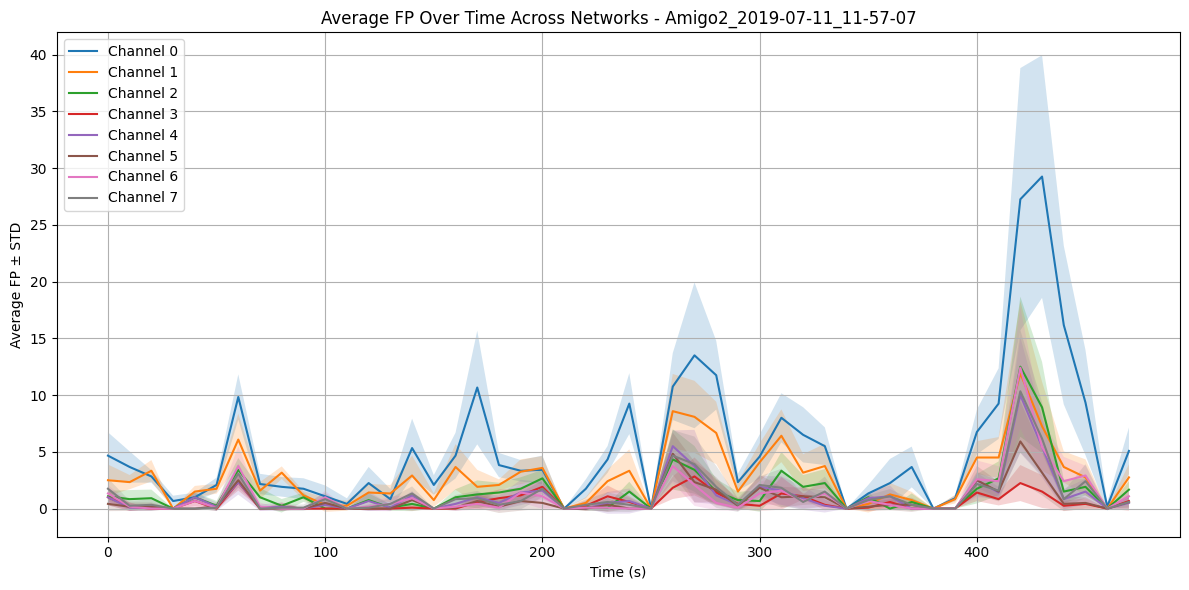

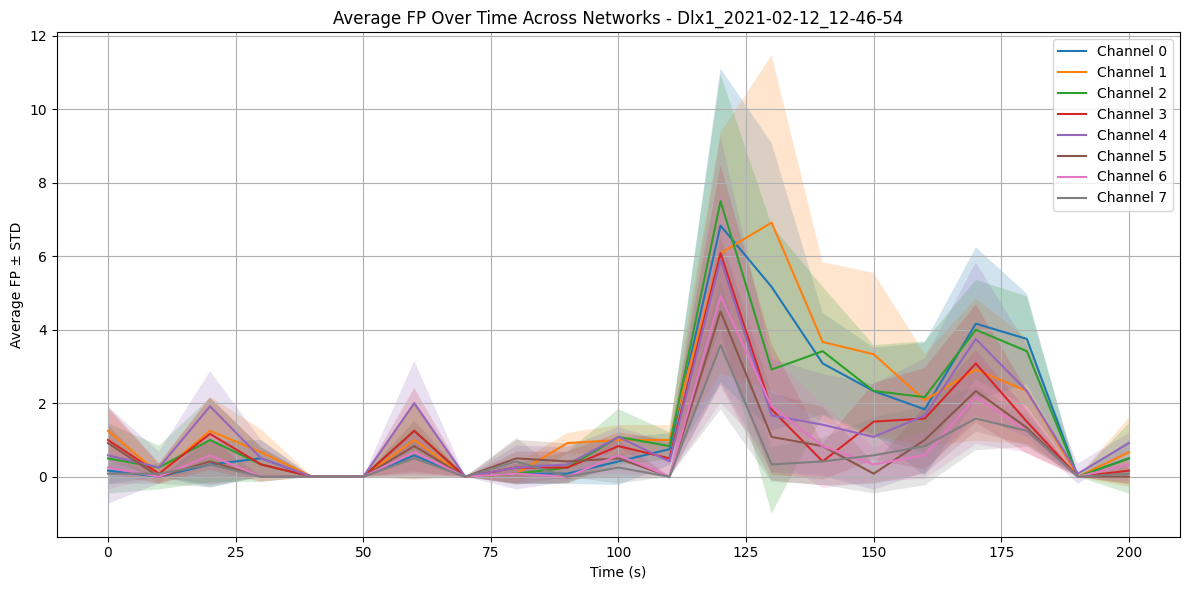

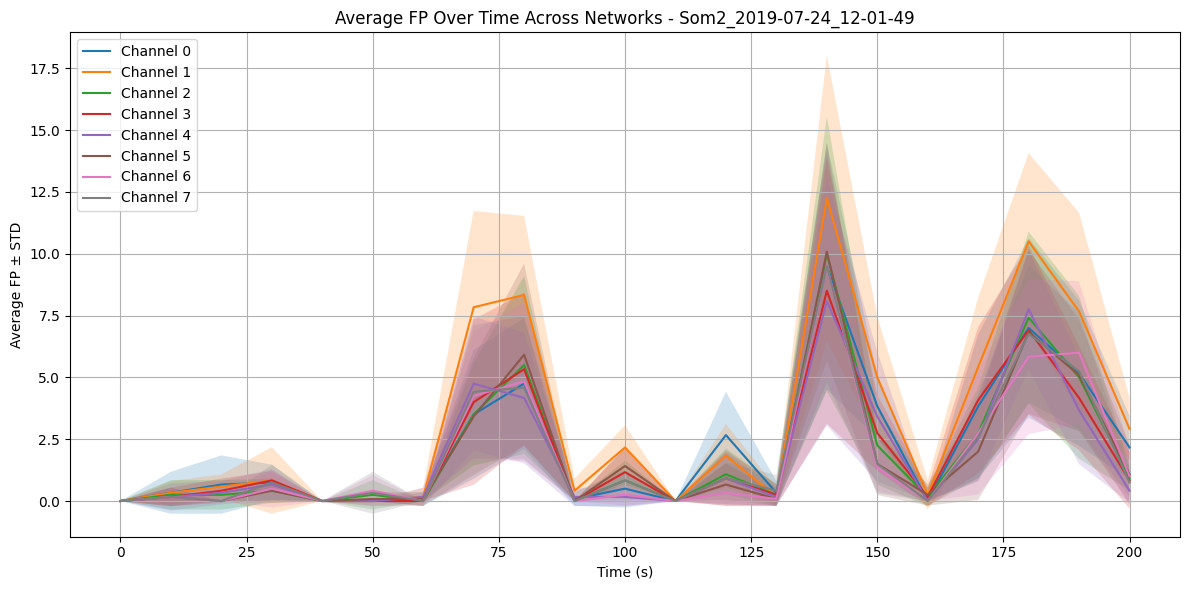

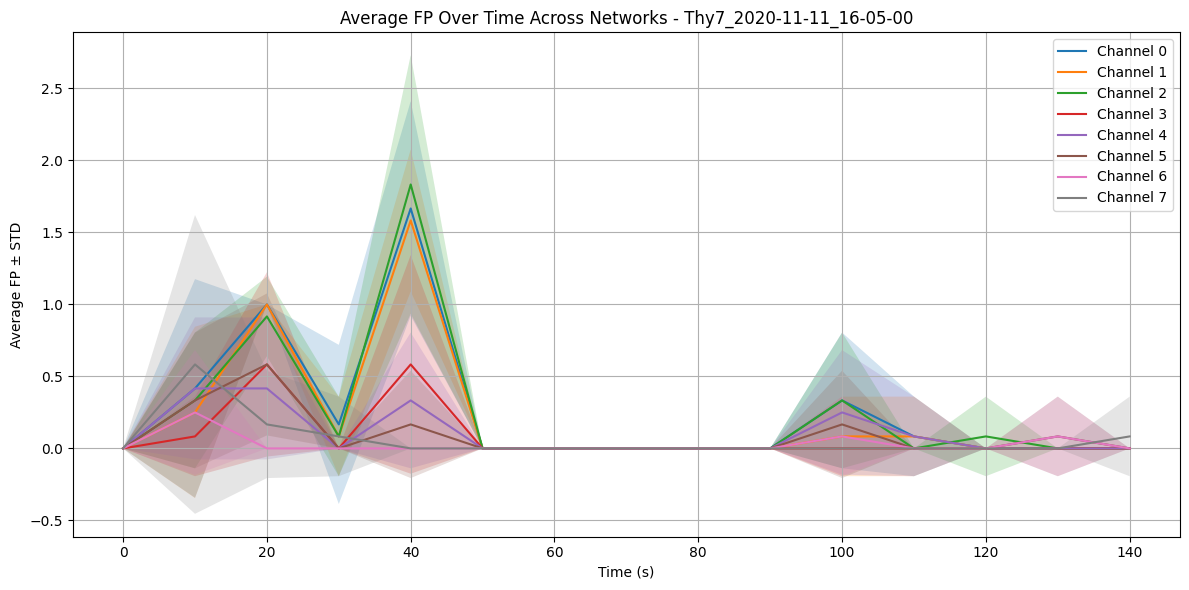

In [299]:
from collections import defaultdict
import numpy as np
import matplotlib.pyplot as plt

var = "FP"  # or "TP" or "FN"

# Store average and std: dataset -> channel -> {"mean": [...], "std": [...]}
avg_std_metric_by_dataset = defaultdict(lambda: defaultdict(lambda: {"mean": [], "std": []}))

# Step 1: Compute average and std per window across networks
for dataset_name in window_metrics_by_dataset[next(iter(window_metrics_by_dataset))].keys():
    channels = window_metrics_by_dataset[next(iter(window_metrics_by_dataset))][dataset_name].keys()

    for ch in channels:
        # Max number of windows across networks
        max_windows = max(
            len(window_metrics_by_dataset[net][dataset_name][ch][var])
            for net in window_metrics_by_dataset
            if ch in window_metrics_by_dataset[net][dataset_name]
        )

        for win_idx in range(max_windows):
            vals = []
            for net in window_metrics_by_dataset:
                ch_data = window_metrics_by_dataset[net][dataset_name].get(ch, {})
                metric_list = ch_data.get(var, [])
                if win_idx < len(metric_list):
                    vals.append(metric_list[win_idx])

            avg = np.mean(vals) if vals else 0
            std = np.std(vals) if vals else 0

            avg_std_metric_by_dataset[dataset_name][ch]["mean"].append(avg)
            avg_std_metric_by_dataset[dataset_name][ch]["std"].append(std)

# Step 2: Plot mean ± std over time
for dataset_name, channels in avg_std_metric_by_dataset.items():
    plt.figure(figsize=(12, 6))
    plt.title(f"Average {var} Over Time Across Networks - {dataset_name}")

    for ch, metrics in channels.items():
        mean_vals = metrics["mean"]
        std_vals = metrics["std"]
        times = np.arange(len(mean_vals)) * overlap  # Convert to seconds

        plt.plot(times, mean_vals, label=f"Channel {ch}")
        plt.fill_between(times,
                         np.array(mean_vals) - np.array(std_vals),
                         np.array(mean_vals) + np.array(std_vals),
                         alpha=0.2)

    plt.xlabel("Time (s)")
    plt.ylabel(f"Average {var} ± STD")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()


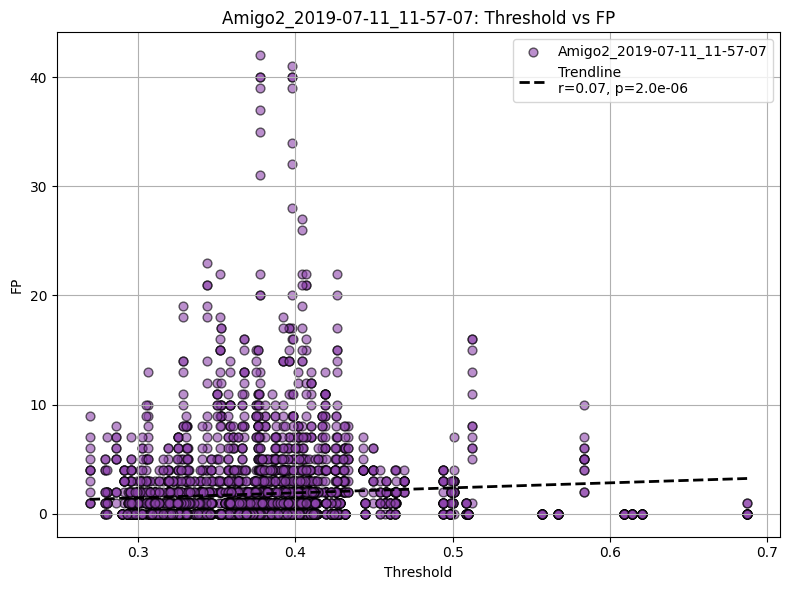

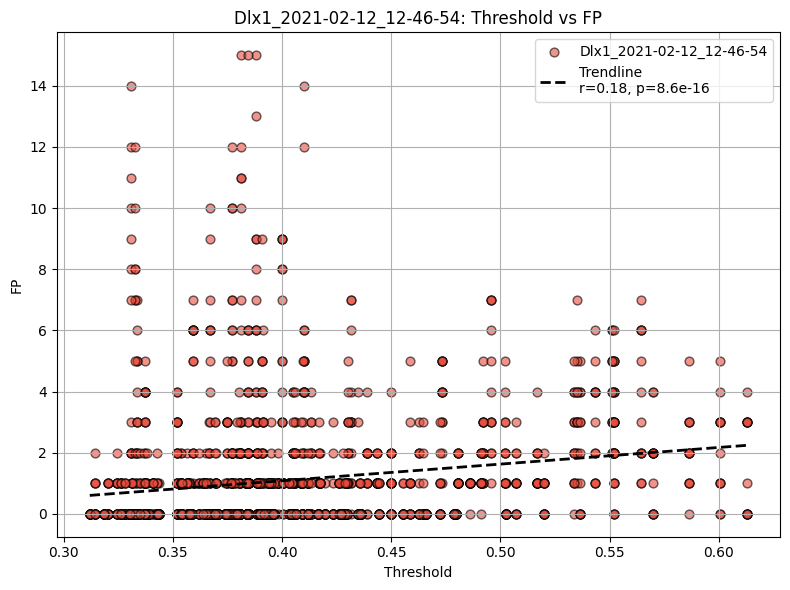

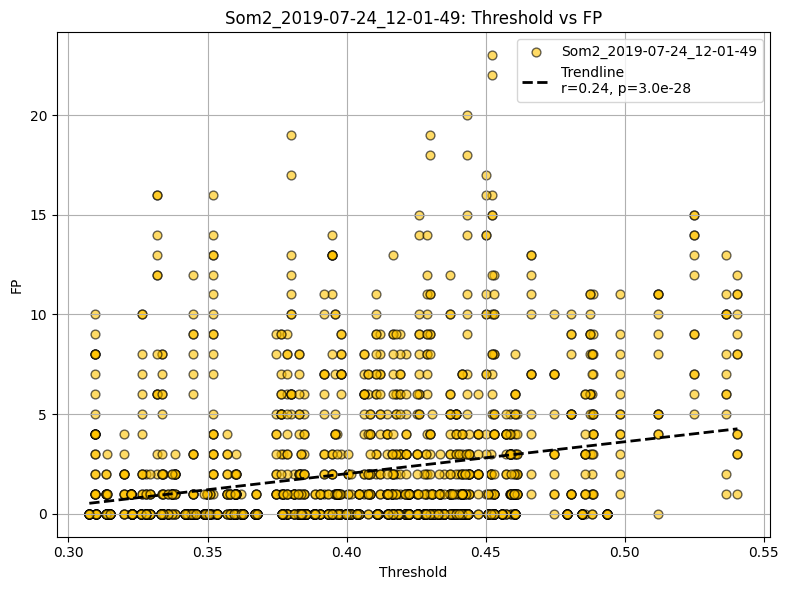

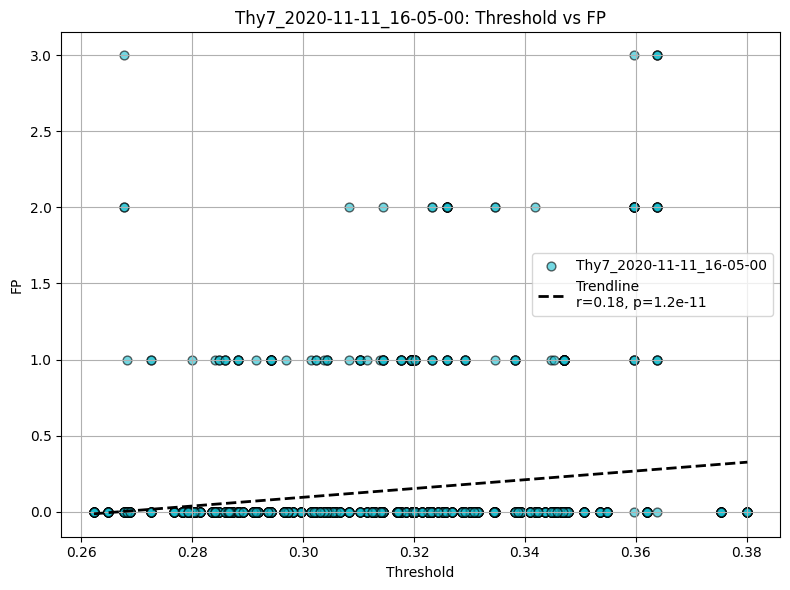

In [300]:
from scipy.stats import pearsonr
import matplotlib.pyplot as plt
import numpy as np

# colors = plt.cm.tab10.colors  # Use tab10 colormap
var = "FP"  # or "TP", "FN", etc.

for i, dataset_name in enumerate(window_metrics_by_dataset[next(iter(window_metrics_by_dataset))].keys()):
    thresholds_all = []
    metrics_all = []

    for net_name in window_metrics_by_dataset.keys():
        if dataset_name not in window_metrics_by_dataset[net_name]:
            continue  # Skip if this network doesn't contain the dataset

        for ch in window_metrics_by_dataset[net_name][dataset_name].keys():
            thresholds = window_metrics_by_dataset[net_name][dataset_name][ch]["threshold"]
            metrics = window_metrics_by_dataset[net_name][dataset_name][ch][var]

            # Filter out None values
            filtered = [(t, m) for t, m in zip(thresholds, metrics) if t is not None]
            if not filtered:
                continue

            t_vals, m_vals = zip(*filtered)
            thresholds_all.extend(t_vals)
            metrics_all.extend(m_vals)

    if not thresholds_all:
        continue  # Skip if no data

    # Calculate correlation and trendline
    r_val, p_val = pearsonr(thresholds_all, metrics_all)
    slope, intercept = np.polyfit(thresholds_all, metrics_all, 1)
    x_vals = np.array([min(thresholds_all), max(thresholds_all)])
    y_vals = slope * x_vals + intercept

    # Plot
    plt.figure(figsize=(8, 6))
    plt.scatter(thresholds_all, metrics_all, alpha=0.6, s=40,
                color=dataset_colors[labels[i]], edgecolors='k', label=f"{dataset_name}")
    plt.plot(x_vals, y_vals, color="black", linestyle='--', linewidth=2, label=f"Trendline\nr={r_val:.2f}, p={p_val:.1e}")

    plt.title(f"{dataset_name}: Threshold vs {var}")
    plt.xlabel("Threshold")
    plt.ylabel(var)
    plt.grid(True)
    plt.legend()
    plt.tight_layout()
    plt.show()


Figure saved to:overall_threshold_vs_FP.png


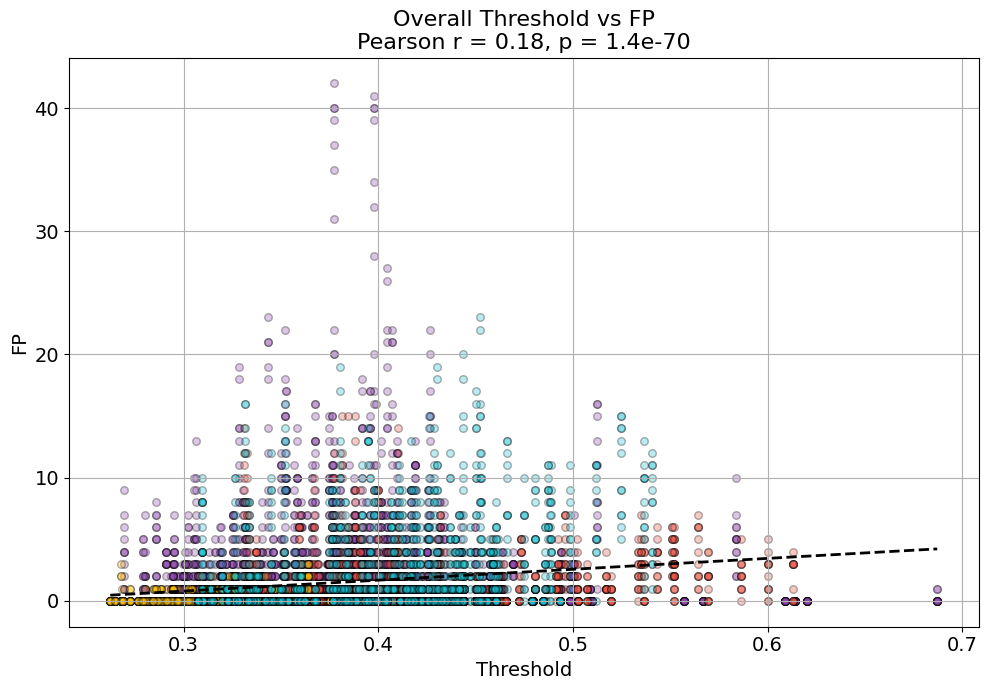

In [303]:
from scipy.stats import pearsonr
import matplotlib.pyplot as plt
import numpy as np

var = "FP"  # Change to "TP" or "FN" as needed

threshold_all = []
metrics_all = []
dataset_labels = []

# Step 1: Collect all thresholds and metrics per dataset across all networks
for net_name in window_metrics_by_dataset.keys():
    for dataset_name in window_metrics_by_dataset[net_name].keys():
        for ch in window_metrics_by_dataset[net_name][dataset_name].keys():
            thresholds = window_metrics_by_dataset[net_name][dataset_name][ch].get("threshold", [])
            metrics = window_metrics_by_dataset[net_name][dataset_name][ch].get(var, [])

            # Filter out None thresholds
            filtered = [(t, m) for t, m in zip(thresholds, metrics) if t is not None]
            if not filtered:
                continue

            t_vals, m_vals = zip(*filtered)
            threshold_all.extend(t_vals)
            metrics_all.extend(m_vals)
            dataset_labels.extend([dataset_name] * len(t_vals))

# Step 2: Prepare figure
fig, ax = plt.subplots(figsize=(10, 7))
unique_datasets = list(set(dataset_labels))

# Scatter points by dataset
for i, dataset_name in enumerate(unique_datasets):
    dataset_thresholds = [t for t, label in zip(threshold_all, dataset_labels) if label == dataset_name]
    dataset_metrics = [m for m, label in zip(metrics_all, dataset_labels) if label == dataset_name]

    ax.scatter(
        dataset_thresholds,
        dataset_metrics,
        alpha=0.3, s=30,
        c=[dataset_colors[labels[i]]],
        edgecolors='k',
        label=dataset_name
    )

# Step 3: Compute and plot overall trendline
r_all, p_all = pearsonr(threshold_all, metrics_all)
slope, intercept = np.polyfit(threshold_all, metrics_all, 1)
x_vals = np.array([min(threshold_all), max(threshold_all)])
y_vals = slope * x_vals + intercept

ax.plot(x_vals, y_vals, color='black', linestyle='--', linewidth=2, label="Trendline")

# Step 4: Final formatting
ax.set_title(f"Overall Threshold vs {var}\nPearson r = {r_all:.2f}, p = {p_all:.1e}",fontsize=16)
ax.set_xlabel("Threshold",fontsize=14)
ax.set_ylabel(var,fontsize=14)
ax.tick_params(axis='both', which='major', labelsize=14)
# ax.legend()
ax.grid(True)
fig.tight_layout()
if adapt>0:
    filename= f"overall_threshold_vs_{var}_adapt{adapt}.png"
else:
    filename= f"overall_threshold_vs_{var}.png"
fig.savefig(filename, dpi=300)
print(f"Figure saved to:{filename}")


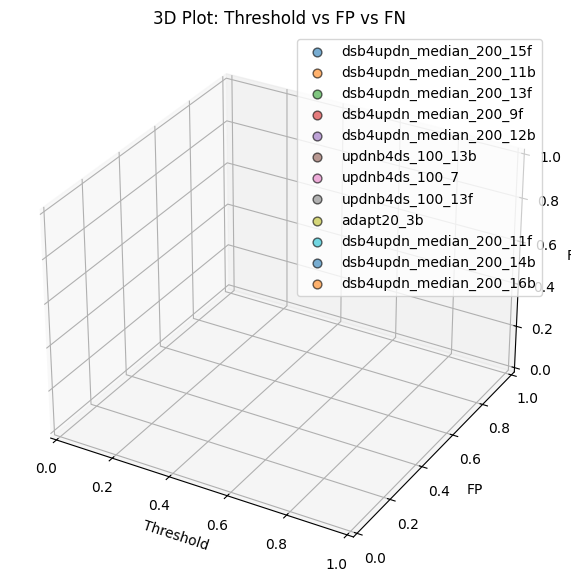

In [302]:
from mpl_toolkits.mplot3d import Axes3D
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
import numpy as np

var = "FP"
third_var = "FN"

fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection='3d')

# Collect all data first
for i, dataset_name in enumerate(window_metrics_by_dataset.keys()):
    thresholds_dataset = []
    metric_dataset = []
    third_dataset = []

    for ch in window_metrics_by_dataset[dataset_name].keys():
        thresholds = window_metrics_by_dataset[dataset_name][ch]["threshold"]
        metric_values = window_metrics_by_dataset[dataset_name][ch][var]
        third_values = window_metrics_by_dataset[dataset_name][ch][third_var]

        if not (len(thresholds) == len(metric_values) == len(third_values)):
            continue

        thresholds_dataset.extend(thresholds)
        metric_dataset.extend(metric_values)
        third_dataset.extend(third_values)

    ax.scatter(
        thresholds_dataset,
        metric_dataset,
        third_dataset,
        color=colors[i % len(colors)],
        label=dataset_name,
        alpha=0.6,
        edgecolor='k',
        s=40
    )

ax.set_xlabel("Threshold")
ax.set_ylabel(var)
ax.set_zlabel(third_var)
ax.set_title(f"3D Plot: Threshold vs {var} vs {third_var}")
ax.legend()

# Animation function
def update(angle):
    ax.view_init(elev=20, azim=angle)
    return fig,

# Animate
ani = FuncAnimation(fig, update, frames=np.arange(0, 360, 2), interval=50)

# To display in Jupyter:
plt.show()

# To save as a video or GIF:
# ani.save("rotation.gif", writer='pillow', fps=20)
# ani.save("rotation.mp4", writer='ffmpeg', fps=20)


In [ ]:
adapt=20
identifier="30000_1000_100"
identifier=f"{identifier}_adaptable{adapt}" if adapt>0 else f"{identifier}"
# identifier="1000_200_median"
dataset_path=os.path.join(os.getcwd(),os.pardir,"train_pedro","dataset_up_down",identifier)
datasets=os.listdir(dataset_path)
if "config.json" in datasets:
    datasets.remove("config.json")

results_path=os.path.join(os.getcwd(),os.pardir,os.pardir,"snnTorch","eval","live_results")
filename=f"all_network_results_{identifier}.pkl"
path_file=os.path.join(results_path, filename)
with open(path_file, "rb") as f:
    all_results_adaptable = pkl.load(f)
    print(f"Loaded {len(all_results_adaptable)} results from {filename}")

Loaded 12 results from all_network_results_30000_1000_100_adaptable20.pkl


In [ ]:
# Nested structure: net -> dataset -> channel -> window_idx -> metrics dict
threshold_tp_fp_fn_by_window_2 = defaultdict(
    lambda: defaultdict(lambda: defaultdict(dict))
)

# Nested structure: net -> dataset -> channel -> list of metrics
window_metrics_by_dataset_2 = defaultdict(
    lambda: defaultdict(lambda: defaultdict(lambda: defaultdict(list)))
)

# NEW OUTER LOOP
for net_name, information_dataset in all_results_adaptable.items():
    for dataset_name, info in information_dataset.items():
        data_path = os.path.join(dataset_path, dataset_name)
        ripple_hits = info["ripple_hits"]
        ripples = np.load(os.path.join(data_path, "ripples.npy"))
        data = np.load(os.path.join(data_path, "spike_data.npy"))
        filtered_spikes = info["filtered_spikes"]

        for ch, ch_spikes in enumerate(filtered_spikes):
            ch_thresholds = extracted_thresholds[dataset_name][str(ch)]
            ch_rates = extracted_spike_rates[dataset_name][str(ch)]

            max_time = int(data.shape[0])
            n_windows = int(np.ceil(max_time / (overlap * 1000)))

            for window_idx in range(n_windows):
                start_time = window_idx * overlap * 1000
                end_time = start_time + overlap * 1000
                spikes_in_window = ch_spikes[(ch_spikes >= start_time) & (ch_spikes < end_time)]

                ripples_in_window = []
                ripple_ids_in_window = []
                for i, ripple in enumerate(ripples):
                    ripple_start = ripple[0] - tolerance
                    ripple_end = ripple[0] + max_detection_offset + tolerance
                    if not (ripple_end < start_time or ripple_start > end_time):
                        ripples_in_window.append((ripple_start, ripple_end))
                        ripple_ids_in_window.append(i)

                TP = 0
                FP = 0
                FN = 0
                matched_spikes = set()

                for ripple_idx in ripple_ids_in_window:
                    if ripple_idx in ripple_hits and ch in ripple_hits[ripple_idx]:
                        TP += 1
                    else:
                        FN += 1

                for spike_time in spikes_in_window:
                    for r_start, r_end in ripples_in_window:
                        if r_start-tolerance <= spike_time <= r_start +max_detection_offset + tolerance:
                            matched_spikes.add(spike_time)
                            break

                last_fp_time = -np.inf
                for spike_time in spikes_in_window:
                    if spike_time in matched_spikes:
                        continue
                    if any(spike_time <= r_start +max_detection_offset + tolerance + padding for (r_start, _) in ripples_in_window):
                        continue
                    if spike_time - last_fp_time > jitter:
                        FP += 1
                        last_fp_time = spike_time

                # Fetch threshold + rate
                threshold = ch_thresholds[window_idx] if window_idx < len(ch_thresholds) else None
                rate = ch_rates[window_idx] if window_idx < len(ch_rates) else None

                # ✅ Store per-network results
                threshold_tp_fp_fn_by_window_2[net_name][dataset_name][ch][window_idx] = {
                    "TP": TP, "FP": FP, "FN": FN, "threshold": threshold, "rate": rate
                }
                window_metrics_by_dataset_2[net_name][dataset_name][ch]["TP"].append(TP)
                window_metrics_by_dataset_2[net_name][dataset_name][ch]["FP"].append(FP)
                window_metrics_by_dataset_2[net_name][dataset_name][ch]["FN"].append(FN)
                window_metrics_by_dataset_2[net_name][dataset_name][ch]["threshold"].append(threshold)
                window_metrics_by_dataset_2[net_name][dataset_name][ch]["rate"].append(rate)

                print(f"[{net_name}] Dataset: {dataset_name}, Channel: {ch}, Window: {window_idx}, "
                      f"TP: {TP}, FP: {FP}, FN: {FN}, Threshold: {threshold}, Rate: {rate}")


[dsb4updn_median_200_15f] Dataset: Amigo2_2019-07-11_11-57-07, Channel: 0, Window: 0, TP: 6, FP: 2, FN: 4, Threshold: 0.4317, Rate: 63.5
[dsb4updn_median_200_15f] Dataset: Amigo2_2019-07-11_11-57-07, Channel: 0, Window: 1, TP: 6, FP: 2, FN: 1, Threshold: 0.4495, Rate: 55.4
[dsb4updn_median_200_15f] Dataset: Amigo2_2019-07-11_11-57-07, Channel: 0, Window: 2, TP: 3, FP: 1, FN: 0, Threshold: 0.4692, Rate: 57.05
[dsb4updn_median_200_15f] Dataset: Amigo2_2019-07-11_11-57-07, Channel: 0, Window: 3, TP: 5, FP: 0, FN: 0, Threshold: 0.4286, Rate: 78.95
[dsb4updn_median_200_15f] Dataset: Amigo2_2019-07-11_11-57-07, Channel: 0, Window: 4, TP: 7, FP: 1, FN: 2, Threshold: 0.457, Rate: 47.800000000000004
[dsb4updn_median_200_15f] Dataset: Amigo2_2019-07-11_11-57-07, Channel: 0, Window: 5, TP: 8, FP: 1, FN: 2, Threshold: 0.4576, Rate: 68.0
[dsb4updn_median_200_15f] Dataset: Amigo2_2019-07-11_11-57-07, Channel: 0, Window: 6, TP: 4, FP: 3, FN: 0, Threshold: 0.4189, Rate: 88.6
[dsb4updn_median_200_15f] 

In [ ]:
from scipy.stats import ttest_rel, wilcoxon
import numpy as np

metrics_to_compare = ["FP", "FN"]
comparison_results = {}

# Shared networks
shared_nets = set(window_metrics_by_dataset.keys()) & set(window_metrics_by_dataset_2.keys())

# We want to pool values per dataset across all networks
for metric in metrics_to_compare:
    print(f"\nComparing metric: {metric}")

    # Prepare dict: dataset_name -> lists of vals
    pooled_fixed_per_dataset = {}
    pooled_adapt_per_dataset = {}

    # For collecting overall data across all networks and datasets
    overall_fixed_vals = []
    overall_adaptive_vals = []

    # First collect all values grouped by dataset across networks
    for net_name in shared_nets:
        # datasets common in both versions for this network
        datasets = set(window_metrics_by_dataset[net_name].keys()) & set(window_metrics_by_dataset_2[net_name].keys())

        for dataset_name in datasets:
            if dataset_name not in pooled_fixed_per_dataset:
                pooled_fixed_per_dataset[dataset_name] = []
                pooled_adapt_per_dataset[dataset_name] = []

            channels = set(window_metrics_by_dataset[net_name][dataset_name].keys()) & \
                       set(window_metrics_by_dataset_2[net_name][dataset_name].keys())

            for ch in channels:
                vals_fixed = window_metrics_by_dataset[net_name][dataset_name][ch][metric]
                vals_adapt = window_metrics_by_dataset_2[net_name][dataset_name][ch][metric]

                n_windows = min(len(vals_fixed), len(vals_adapt))
                # print("FIXED",vals_fixed)
                # print("ADAPT",vals_adapt)
                for w in range(n_windows):
                    fixed_val = vals_fixed[w]
                    adaptive_val = vals_adapt[w]

                    if fixed_val is not None and adaptive_val is not None:
                        pooled_fixed_per_dataset[dataset_name].append(fixed_val)
                        # print(fixed_val, adaptive_val)
                        pooled_adapt_per_dataset[dataset_name].append(adaptive_val)

                        overall_fixed_vals.append(fixed_val)
                        overall_adaptive_vals.append(adaptive_val)

    # Now do stats per dataset
    for dataset_name in pooled_fixed_per_dataset:
        fixed_vals = pooled_fixed_per_dataset[dataset_name]
        adaptive_vals = pooled_adapt_per_dataset[dataset_name]

        if not fixed_vals or not adaptive_vals:
            print(f"No data for dataset {dataset_name}, skipping...")
            continue

        try:
            stat, p_val = wilcoxon(fixed_vals, adaptive_vals)
        except ValueError:
            stat, p_val = ttest_rel(fixed_vals, adaptive_vals)

        mean_fixed = np.mean(fixed_vals)
        mean_adaptive = np.mean(adaptive_vals)
        std_fixed = np.std(fixed_vals)
        std_adaptive = np.std(adaptive_vals)

        print(f"Dataset: {dataset_name}")
        print(f"  {metric} (Fixed):    {mean_fixed:.2f} ± {std_fixed:.2f}")
        print(f"  {metric} (Adaptive): {mean_adaptive:.2f} ± {std_adaptive:.2f}")
        print(f"  p-value: {p_val:.3e}")

        comparison_results[(dataset_name, metric)] = {
            "mean_fixed": mean_fixed,
            "mean_adaptive": mean_adaptive,
            "p": p_val
        }

    # Overall test across all datasets & networks
    try:
        overall_stat, overall_p = wilcoxon(overall_fixed_vals, overall_adaptive_vals)
    except ValueError:
        overall_stat, overall_p = ttest_rel(overall_fixed_vals, overall_adaptive_vals)

    print(f"\nOverall {metric} comparison across all networks and datasets:")
    print(f"  Fixed mean:    {np.mean(overall_fixed_vals):.2f}")
    print(f"  Adaptive mean: {np.mean(overall_adaptive_vals):.2f}")
    print(f"  p-value:       {overall_p:.3e}")



Comparing metric: FP
Dataset: Amigo2_2019-07-11_11-57-07
  FP (Fixed):    1.80 ± 3.54
  FP (Adaptive): 0.97 ± 1.73
  p-value: 5.554e-136
Dataset: Dlx1_2021-02-12_12-46-54
  FP (Fixed):    1.10 ± 1.94
  FP (Adaptive): 0.62 ± 1.41
  p-value: 2.430e-56
Dataset: Thy7_2020-11-11_16-05-00
  FP (Fixed):    0.13 ± 0.42
  FP (Adaptive): 0.10 ± 0.35
  p-value: 7.832e-03
Dataset: Som2_2019-07-24_12-01-49
  FP (Fixed):    2.06 ± 3.42
  FP (Adaptive): 0.89 ± 2.02
  p-value: 8.154e-130

Overall FP comparison across all networks and datasets:
  Fixed mean:    1.47
  Adaptive mean: 0.76
  p-value:       0.000e+00

Comparing metric: FN
Dataset: Amigo2_2019-07-11_11-57-07
  FN (Fixed):    1.81 ± 2.27
  FN (Adaptive): 2.07 ± 2.43
  p-value: 4.549e-68
Dataset: Dlx1_2021-02-12_12-46-54
  FN (Fixed):    0.44 ± 0.70
  FN (Adaptive): 0.46 ± 0.68
  p-value: 4.661e-02
Dataset: Thy7_2020-11-11_16-05-00
  FN (Fixed):    4.45 ± 3.80
  FN (Adaptive): 4.79 ± 3.92
  p-value: 3.319e-19
Dataset: Som2_2019-07-24_12-01-

48


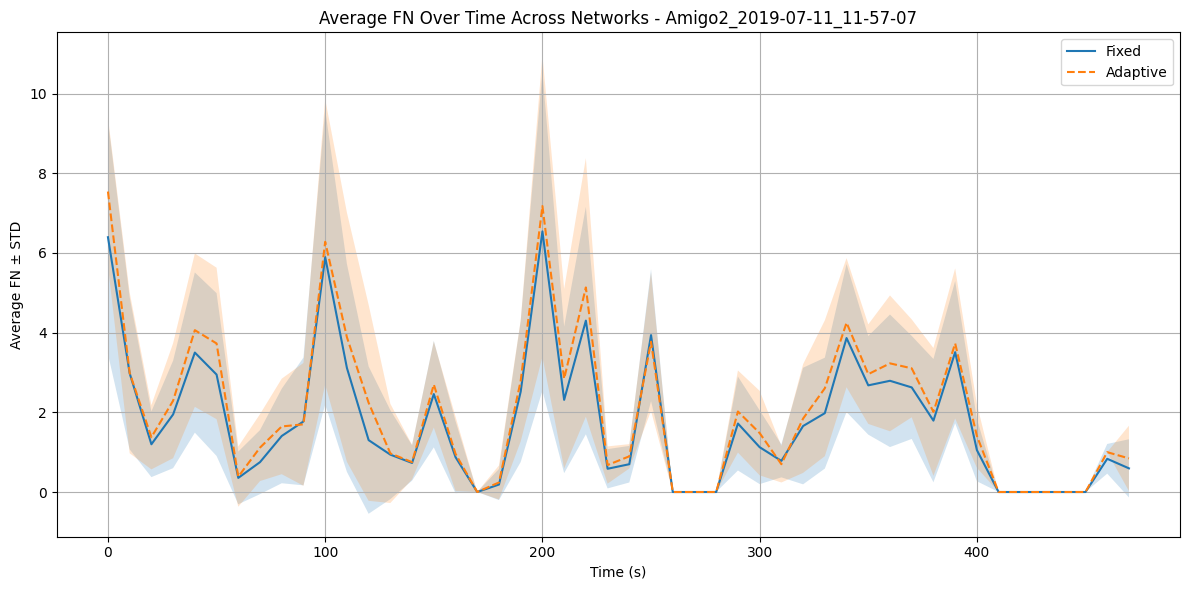

21


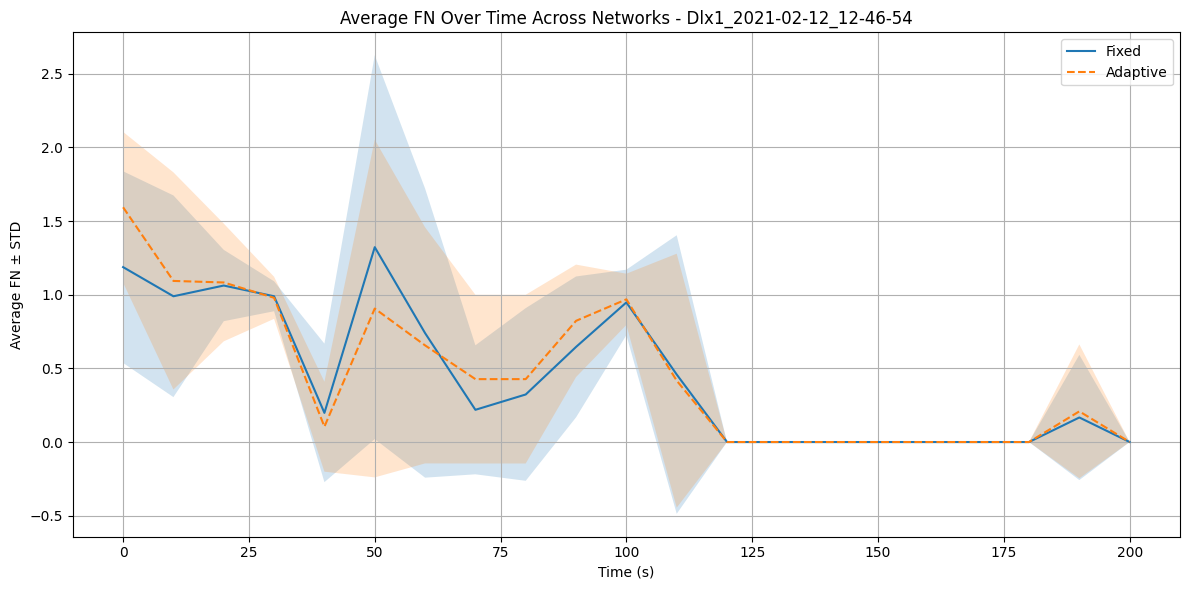

21


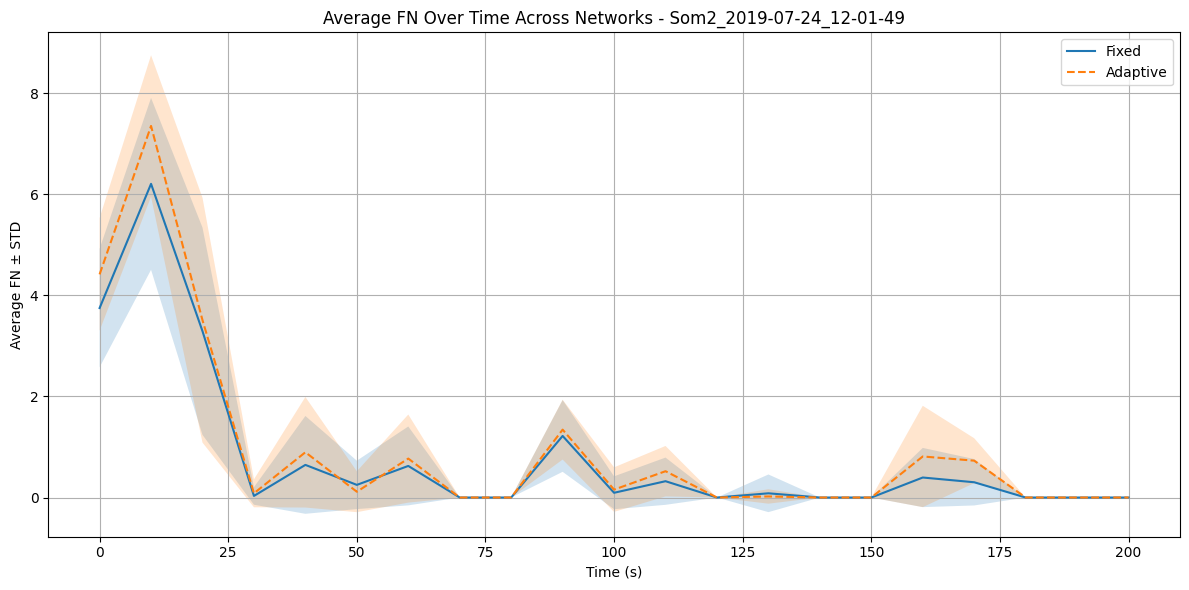

15


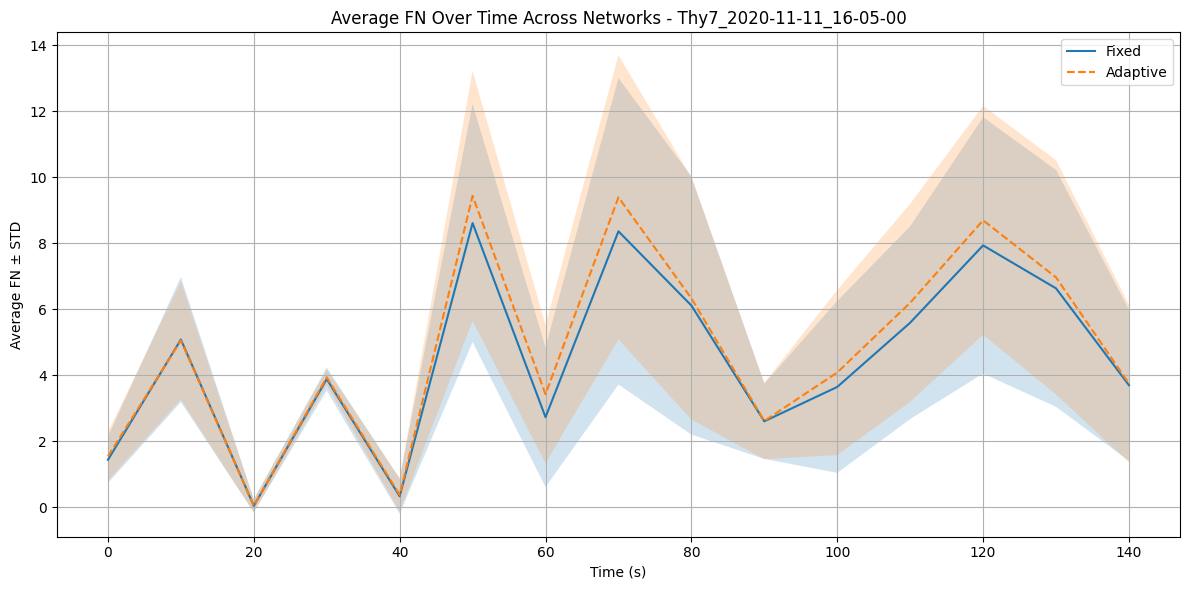

In [148]:
from collections import defaultdict
import numpy as np
import matplotlib.pyplot as plt

var = "FN"  # or "TP" or "FN"

# Store average and std: dataset -> channel -> {"mean": [...], "std": [...]}
avg_std_metric_by_dataset = defaultdict(lambda: {"mean": [], "std": []})
avg_std_metric_by_dataset_adaptable = defaultdict(lambda: {"mean": [], "std": []})

# Step 1: Compute average and std per window across networks
for dataset_name in window_metrics_by_dataset[next(iter(window_metrics_by_dataset))].keys():
    channels = window_metrics_by_dataset[next(iter(window_metrics_by_dataset))][dataset_name].keys()

    for win_idx in range(len(window_metrics_by_dataset[net][dataset_name][1][var])):
        # # Max number of windows across networks
        # max_windows = max(
        #     len(window_metrics_by_dataset[net][dataset_name][ch][var])
        #     for net in window_metrics_by_dataset
        #     if ch in window_metrics_by_dataset[net][dataset_name]
        # )
        vals = []
        ad_vals=[]
        for ch in channels:
            for net in window_metrics_by_dataset:
                ch_data = window_metrics_by_dataset[net][dataset_name].get(ch, {})
                ad_data=window_metrics_by_dataset_2[net][dataset_name].get(ch, {}) 
                metric_adapt= ad_data.get(var, [])               
                metric_list = ch_data.get(var, [])
                if win_idx < len(metric_list):
                    vals.append(metric_list[win_idx])
                    ad_vals.append(metric_adapt[win_idx])

        avg = np.mean(vals) if vals else 0
        std = np.std(vals) if vals else 0
        avg_ad= np.mean(ad_vals) if ad_vals else 0
        std_ad = np.std(ad_vals) if ad_vals else 0
        avg_std_metric_by_dataset[dataset_name]["mean"].append(avg)
        avg_std_metric_by_dataset[dataset_name]["std"].append(std)
        avg_std_metric_by_dataset_adaptable[dataset_name]["mean"].append(avg_ad)
        avg_std_metric_by_dataset_adaptable[dataset_name]["std"].append(std_ad)

# Step 2: Plot mean ± std over time
for dataset_name in avg_std_metric_by_dataset.keys():
    plt.figure(figsize=(12, 6))
    plt.title(f"Average {var} Over Time Across Networks - {dataset_name}")
    metrics= avg_std_metric_by_dataset[dataset_name]
    metrics_ad= avg_std_metric_by_dataset_adaptable[dataset_name]

    mean_vals = metrics["mean"]
    std_vals = metrics["std"]
    print(len(mean_vals))
    times = np.arange(len(mean_vals)) * overlap  # Convert to seconds

    plt.plot(times, mean_vals, label="Fixed")
    plt.fill_between(times,
                        np.array(mean_vals) - np.array(std_vals),
                        np.array(mean_vals) + np.array(std_vals),
                        alpha=0.2)
    mean_vals_ad = metrics_ad["mean"]
    std_vals_ad = metrics_ad["std"]
    plt.plot(times, mean_vals_ad, label=f"Adaptive", linestyle='--')
    plt.fill_between(times,
                        np.array(mean_vals_ad) - np.array(std_vals_ad),
                        np.array(mean_vals_ad) + np.array(std_vals_ad),
                        alpha=0.2, linestyle='--')

    plt.xlabel("Time (s)")
    plt.ylabel(f"Average {var} ± STD")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()
